In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [10]:
import pandas as pd

df = pd.read_csv(r"C:\ml\p\diabetic_retinopathy\data\train.csv")

df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [13]:
print("Number of images:", len(df))
print("Columns:", df.columns.tolist())
print(df.isnull().sum())
print(df["diagnosis"].value_counts().sort_index())

Number of images: 3662
Columns: ['id_code', 'diagnosis']
id_code      0
diagnosis    0
dtype: int64
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


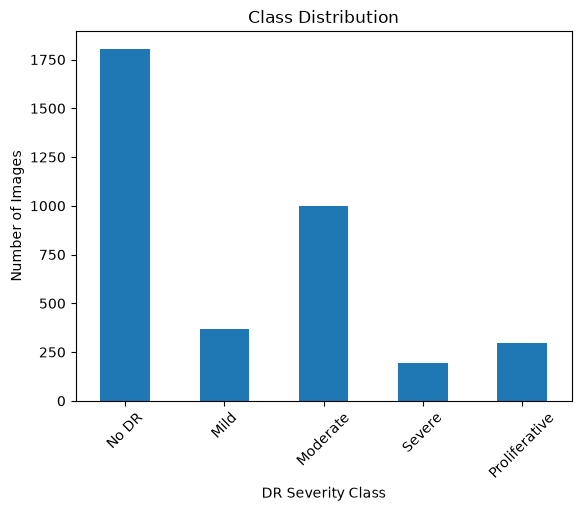

In [14]:
df["diagnosis"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("DR Severity Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(
    [0, 1, 2, 3, 4],
    ["No DR", "Mild", "Moderate", "Severe", "Proliferative"],
    rotation=45
)

plt.show()

Image path: C:\ml\p\diabetic_retinopathy\data\train_images\000c1434d8d7.png
Exists: True


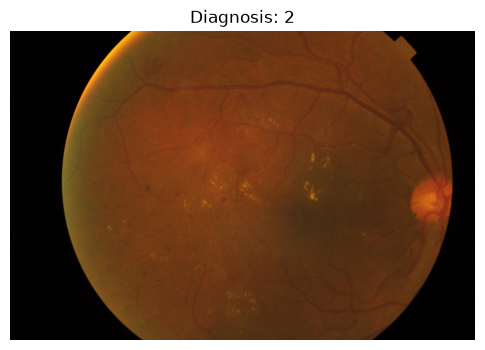

In [17]:
import os
import cv2
import matplotlib.pyplot as plt

IMG_DIR = r"C:\ml\p\diabetic_retinopathy\data\train_images"

row = df.iloc[0]

image_path = os.path.join(
    IMG_DIR,
    row["id_code"] + ".png"
)

print("Image path:", image_path)
print("Exists:", os.path.exists(image_path))

image = cv2.imread(image_path)

if image is None:
    print("❌ Could not load image")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Diagnosis: {row['diagnosis']}")
    plt.axis("off")
    plt.show()

Trying: C:\ml\p\diabetic_retinopathy\data\train_images\000c1434d8d7.png
Trying: C:\ml\p\diabetic_retinopathy\data\train_images\001639a390f0.png
Trying: C:\ml\p\diabetic_retinopathy\data\train_images\0024cdab0c1e.png
Trying: C:\ml\p\diabetic_retinopathy\data\train_images\002c21358ce6.png
Trying: C:\ml\p\diabetic_retinopathy\data\train_images\005b95c28852.png


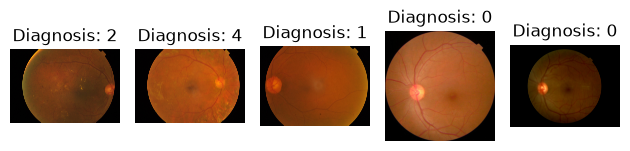

In [19]:
for i in range(5):
    sample = df.iloc[i]

    path = os.path.join(
        IMG_DIR,
        sample["id_code"] + ".png"
    )

    print("Trying:", path)

    image = cv2.imread(path)

    if image is None:
        print("❌ Image not found:", path)
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(f"Diagnosis: {sample['diagnosis']}")
    plt.axis("off")

plt.tight_layout()
plt.show()